<a href="https://colab.research.google.com/github/tatyanakrivonogova/machine-learning-methods/blob/master/%D0%91%D0%BB%D0%BE%D0%BA_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Кластеризация

## k-means, k-means++
Метод K-means – это алгоритм кластеризации, который разделяет объекты на K кластеров, минимизируя сумму квадратов расстояний от объектов до центров кластеров. K-means++ – это улучшенная версия инициализации центроидов.

### Используемые библиотеки

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances_argmin_min

### Датасет

In [25]:
iris = datasets.load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
df = pd.DataFrame(X, columns=feature_names)
print('Первые 5 строк датасета:')
print(df.head())
print('\nРазмер:', X.shape)

Первые 5 строк датасета:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Размер: (150, 4)


### Предварительная обработка датасета

In [26]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Тепловая карта

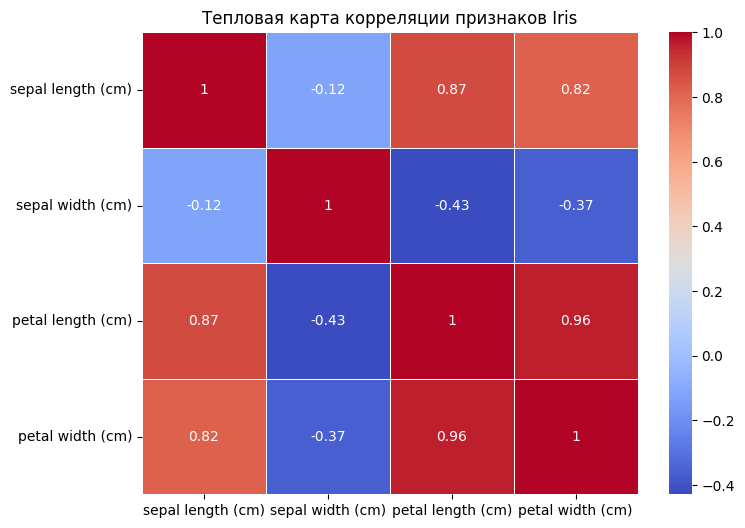

In [27]:
plt.figure(figsize=(8,6))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Тепловая карта корреляции признаков Iris')
plt.show()

### Обучение модели

In [28]:
kmeans_random = KMeans(n_clusters=3, init='random', n_init=10, random_state=42)
kmeans_pp = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)

kmeans_random.fit(X_scaled)
kmeans_pp.fit(X_scaled)

KMeans(n_clusters=3, n_init=10, random_state=42)

### Прогнозы модели

In [29]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, adjusted_rand_score, normalized_mutual_info_score

labels_random = kmeans_random.labels_
labels_pp = kmeans_pp.labels_

print('Метки кластеров для первых 10 объектов (K-means random):', labels_random[:10])
print('Метки кластеров для первых 10 объектов (K-means++):', labels_pp[:10])

print('\nРаспределение по кластерам (K-means random):')
print(pd.Series(labels_random).value_counts().sort_index())
print('\nРаспределение по кластерам (K-means++):')
print(pd.Series(labels_pp).value_counts().sort_index())

# Расчёт метрик для K-means random
sil_random = silhouette_score(X_scaled, labels_random)
ch_random = calinski_harabasz_score(X_scaled, labels_random)
db_random = davies_bouldin_score(X_scaled, labels_random)
ari_random = adjusted_rand_score(y, labels_random)
nmi_random = normalized_mutual_info_score(y, labels_random)

# Расчёт метрик для K-means++
sil_pp = silhouette_score(X_scaled, labels_pp)
ch_pp = calinski_harabasz_score(X_scaled, labels_pp)
db_pp = davies_bouldin_score(X_scaled, labels_pp)
ari_pp = adjusted_rand_score(y, labels_pp)
nmi_pp = normalized_mutual_info_score(y, labels_pp)

print(f"{'Метрика':<20} {'K-means random':>15} {'K-means++':>15}")
print(f"{'Silhouette':<20} {sil_random:>15.4f} {sil_pp:>15.4f}")
print(f"{'Calinski-Harabasz':<20} {ch_random:>15.2f} {ch_pp:>15.2f}")
print(f"{'Davies-Bouldin':<20} {db_random:>15.4f} {db_pp:>15.4f}")
print(f"{'Adjusted Rand Index':<20} {ari_random:>15.4f} {ari_pp:>15.4f}")
print(f"{'NMI':<20} {nmi_random:>15.4f} {nmi_pp:>15.4f}")

Метки кластеров для первых 10 объектов (K-means random): [0 0 0 0 0 0 0 0 0 0]
Метки кластеров для первых 10 объектов (K-means++): [1 1 1 1 1 1 1 1 1 1]

Распределение по кластерам (K-means random):
0    50
1    52
2    48
Name: count, dtype: int64

Распределение по кластерам (K-means++):
0    53
1    50
2    47
Name: count, dtype: int64
Метрика               K-means random       K-means++
Silhouette                    0.4594          0.4599
Calinski-Harabasz             241.89          241.90
Davies-Bouldin                0.8340          0.8336
Adjusted Rand Index           0.6101          0.6201
NMI                           0.6526          0.6595


### Графики выходных результатов

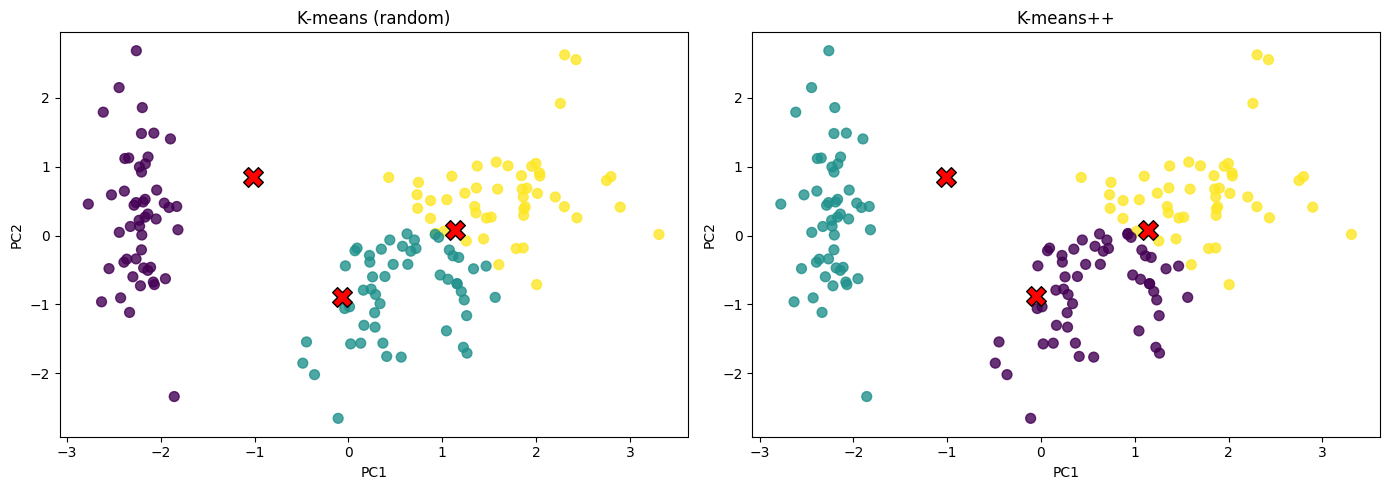

In [30]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].scatter(X_pca[:,0], X_pca[:,1], c=labels_random, cmap='viridis', s=50, alpha=0.8)
axes[0].scatter(kmeans_random.cluster_centers_[:,0], kmeans_random.cluster_centers_[:,1],
                marker='X', s=200, c='red', edgecolors='black', label='Центроиды')
axes[0].set_title('K-means (random)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

axes[1].scatter(X_pca[:,0], X_pca[:,1], c=labels_pp, cmap='viridis', s=50, alpha=0.8)
axes[1].scatter(kmeans_pp.cluster_centers_[:,0], kmeans_pp.cluster_centers_[:,1],
                marker='X', s=200, c='red', edgecolors='black', label='Центроиды')
axes[1].set_title('K-means++')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.show()